# 01 — Fechamento de lacunas do v3 (varredura, validade de critério, poda)

**O que faz:** (1) varre `PEDAL_ACTIVE_PCT` e `MIN_BRAKE_RUN` — prometido no cabeçalho do
v3 e nunca implementado; (2) mede validade de critério por regra (Δt do setor quando a
regra dispara vs. não dispara); (3) calcula co-ocorrência (Jaccard, phi) entre as 12
regras; (4) aplica o critério de poda e decide quais regras entram na rotulagem cega.

**Consome:** `%run 00_core.ipynb` (usa `interp_cache`, `pair_cache`, `df_sector`,
`DRIVING_RULES`, `THRESHOLD_SPEC`, `RULE_BEHAVIOR`, `stint_slopes`, `pattern_stats`,
`pair_cache_rows`).

**Produz:** `data/poc_threshold_validation/results/descriptor_sweep.csv`,
`criterion_per_rule.csv`, `cooccurrence_jaccard.csv`, `cooccurrence_phi.csv`,
`rules_in_poc.csv`, e as figuras correspondentes.

**Ordem de execução:** roda depois de `00_core.ipynb` (que precisa ter o cache
completo — `RUN_FULL_BUILD = True` — para os resultados terem sentido estatístico;
com o cache parcial desta sessão, a lógica é validada mas os números não são
conclusivos, como reportado nas próprias saídas abaixo).

In [1]:
%run 00_core.ipynb

PROJECT_ROOT : C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing
DATA_DIR     : C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\data\poc_threshold_validation
Tracks       : ['charlotte_roval_2025', 'summit_point']
Drivers      : {'Rodrigo': 'Driver A', 'Tomaz': 'Driver B', 'Morsinaldo': 'Driver C', 'Thallys': 'Driver D', 'Igor': 'Driver E', 'Hilton': 'Driver F'}
5 comparisons: ['B vs. A', 'C vs. B', 'D vs. B', 'E vs. B', 'F vs. B']
Self-comparison label: 'B vs. B (self)'
Descriptor functions loaded. DESC_SPEC = {'PEDAL_ACTIVE_PCT': 5.0, 'MIN_BRAKE_RUN': 5}
align_lap_by_dist / assert_pedal_scale loaded.
12 rules, 17 tunable thresholds, 2 descriptor parameters.
  MRP_DT               =     -0.05
  BRAKE_EFF_RATIO      =      0.85
  TRAIL_RATIO          =       0.7
  LEGACY_DV            =        -2
  LEGACY_BRAKE_GATE    =         5
  BRAKE_DIST_TOL       =     0.005
  OVERBRAKE_DELTA      =        15
  ENTRY_SLOW_REL       =    -0.015
  ENTRY_BRAKE_GATE     =    

OK (60,130 samples, laps 0–12)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (13 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 9 laps
  🏆 Fastest : Lap 8  (01:19.767)
  ❌ Invalid : 4 laps
     Lap   0  16:39.700  → LapTime=999.7s | GPS=27.0%<100%
     Lap   1  01:22.067  → IQR_outlier
     Lap   3  01:22.783  → IQR_outlier
     Lap  12  01:22.633  → CompletedPct=0.938<0.995 | GPS=94.0%<100%
──────────────────────────────────────────────────────────────
[SCALE] pedal channels confirmed on a 0-100 scale (brake max = 78.5 %)
pair_cache      : 1 comparison-stints, 18 sector pairs.
pair_cache_self : 1 comparison-stints, 18 sector pairs.
Total activations (cross-driver, current scope): 47
Total activations (self, current scope)        : 31

Cache persisted under C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\data\poc_threshold_validation\cache
stint_slopes / pattern_stats / scenario_summary loade

## 1. Varredura de descritores

`PEDAL_ACTIVE_PCT ∈ {1, 2.5, 5, 7.5, 10, 15}` e `MIN_BRAKE_RUN ∈ {2, 3, 5, 8, 12}`,
um parâmetro por vez (o outro fica no valor de `DESC_SPEC`). Para cada valor:
`build_heur_cache(dp) → build_pair_cache → evaluate_rules(baseline)`. Limiares
(`THRESHOLD_SPEC`) ficam fixos no baseline em toda a varredura -- só os descritores
mudam.

In [2]:
PEDAL_ACTIVE_PCT_GRID = [1, 2.5, 5, 7.5, 10, 15]
MIN_BRAKE_RUN_GRID     = [2, 3, 5, 8, 12]

base_tot  = df_sector.groupby("Rule_ID")["Fired"].sum().reindex(RULE_IDS).fillna(0)
base_rank = base_tot.rank(ascending=False)

sweep_scen_rows, sweep_rule_rows = [], []

for param, grid in (("PEDAL_ACTIVE_PCT", PEDAL_ACTIVE_PCT_GRID),
                    ("MIN_BRAKE_RUN", MIN_BRAKE_RUN_GRID)):
    for value in grid:
        dp = dict(DESC_SPEC)
        dp[param] = value
        if value == DESC_SPEC[param]:
            df_s = df_sector
        else:
            heur_v = build_heur_cache(dp)
            pair_v = build_pair_cache(heur_v)
            df_s   = evaluate_rules(pair_v, thresholds_at())
        summ, tot = scenario_summary(df_s, base_rank)
        sweep_scen_rows.append({"Param": param, "Value": value, **summ})
        for rid in RULE_IDS:
            sweep_rule_rows.append({"Param": param, "Value": value, "Rule_ID": rid,
                                    "Activations": int(tot[rid])})

df_sweep_scen = pd.DataFrame(sweep_scen_rows)
df_sweep_rule = pd.DataFrame(sweep_rule_rows)
df_sweep_scen.to_csv(RESULTS_DIR / "descriptor_sweep_scenarios.csv", index=False)
df_sweep_rule.to_csv(RESULTS_DIR / "descriptor_sweep.csv", index=False)

print(f"{len(df_sweep_scen)} descriptor-sweep scenarios "
      f"({len(PEDAL_ACTIVE_PCT_GRID)} + {len(MIN_BRAKE_RUN_GRID)} values).")
print(f"Saved -> {RESULTS_DIR / 'descriptor_sweep.csv'}")
display(df_sweep_scen)

11 descriptor-sweep scenarios (6 + 5 values).
Saved -> C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\data\poc_threshold_validation\results\descriptor_sweep.csv


,Param,Value,Total,KendallTau,slope_fb,slope_ctrl,margin,preserved
0,PEDAL_ACTIVE_PCT,1.0,48,0.933376,NaN,NaN,NaN,None
1,PEDAL_ACTIVE_PCT,2.5,48,0.933376,NaN,NaN,NaN,None
2,PEDAL_ACTIVE_PCT,5.0,47,1.000000,NaN,NaN,NaN,None
3,PEDAL_ACTIVE_PCT,7.5,46,0.931104,NaN,NaN,NaN,None
4,PEDAL_ACTIVE_PCT,10.0,45,0.921746,NaN,NaN,NaN,None
5,PEDAL_ACTIVE_PCT,15.0,45,0.838133,NaN,NaN,NaN,None
6,MIN_BRAKE_RUN,2.0,48,0.940753,NaN,NaN,NaN,None
7,MIN_BRAKE_RUN,3.0,49,0.764853,NaN,NaN,NaN,None
8,MIN_BRAKE_RUN,5.0,47,1.000000,NaN,NaN,NaN,None
9,MIN_BRAKE_RUN,8.0,47,1.000000,NaN,NaN,NaN,None


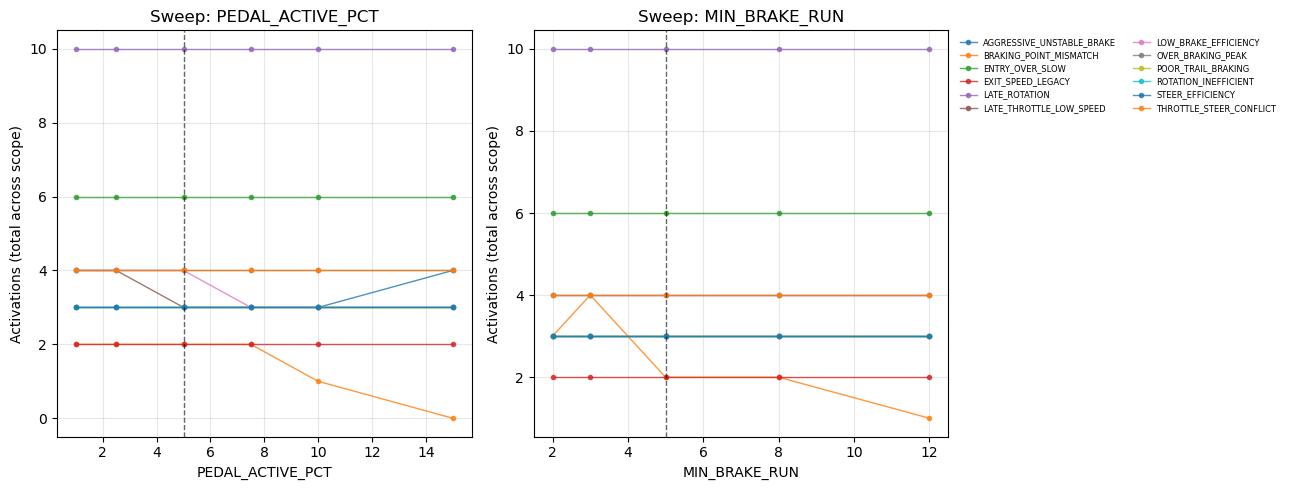

Saved -> fig_descriptor_sweep.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (param, grid) in zip(axes, (("PEDAL_ACTIVE_PCT", PEDAL_ACTIVE_PCT_GRID),
                                    ("MIN_BRAKE_RUN", MIN_BRAKE_RUN_GRID))):
    sub = df_sweep_rule[df_sweep_rule["Param"] == param]
    for rid, g in sub.groupby("Rule_ID"):
        g = g.sort_values("Value")
        ax.plot(g["Value"], g["Activations"], marker="o", markersize=3,
                linewidth=1, alpha=0.8, label=rid)
    ax.axvline(DESC_SPEC[param], color="k", ls="--", lw=1, alpha=0.6)
    ax.set_xlabel(param)
    ax.set_ylabel("Activations (total across scope)")
    ax.set_title(f"Sweep: {param}")
    ax.grid(alpha=0.3)
axes[1].legend(fontsize=6, ncol=2, frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_descriptor_sweep.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved -> fig_descriptor_sweep.png")

## 2. Validade de critério por regra

Para cada regra, Δt do setor (`dts` = `SectorTime_test - SectorTime_ref`, positivo =
piloto testado mais lento) quando a regra dispara vs. não dispara. Teste unilateral
(hipótese: disparo → setor mais lento, `dts` maior) via Mann-Whitney U; tamanho de
efeito via Cliff's delta (`= 2U/(n1*n2) - 1`, equivalente ao U de Mann-Whitney).

In [4]:
from scipy.stats import mannwhitneyu

dts_df = pair_cache_rows(pair_cache)
crit_base = df_sector.merge(dts_df, on=["Track", "Comparison", "Stint", "Sector"], how="left")

crit_rows = []
for rid, g in crit_base.groupby("Rule_ID"):
    fired    = g.loc[g["Fired"] == 1, "dts"].dropna()
    notfired = g.loc[g["Fired"] == 0, "dts"].dropna()
    n_fired  = len(fired)
    row = {"Rule_ID": rid, "n_fired": n_fired, "n_not_fired": len(notfired),
           "median_dts_fired": float(fired.median()) if n_fired else np.nan,
           "median_dts_not_fired": float(notfired.median()) if len(notfired) else np.nan,
           "p_value": np.nan, "cliffs_delta": np.nan}
    if n_fired >= 1 and len(notfired) >= 1:
        U, p = mannwhitneyu(fired, notfired, alternative="greater")
        row["p_value"]      = float(p)
        row["cliffs_delta"] = float(2 * U / (n_fired * len(notfired)) - 1)
    crit_rows.append(row)

df_criterion = pd.DataFrame(crit_rows).set_index("Rule_ID").reindex(RULE_IDS).reset_index()
df_criterion = df_criterion.sort_values("cliffs_delta", ascending=False)
df_criterion.to_csv(RESULTS_DIR / "criterion_per_rule.csv", index=False)

print(f"Saved -> {RESULTS_DIR / 'criterion_per_rule.csv'}")
if crit_base["dts"].isna().all():
    print("[WARN] no dts values available in current scope -- criterion validity is "
          "undefined until the full cache is built (RUN_FULL_BUILD = True).")
display(df_criterion)

Saved -> C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\data\poc_threshold_validation\results\criterion_per_rule.csv


,Rule_ID,n_fired,n_not_fired,median_dts_fired,median_dts_not_fired,p_value,cliffs_delta
2,LOW_BRAKE_EFFICIENCY,4,14,0.245444,0.010474,0.050654,0.571429
3,AGGRESSIVE_UNSTABLE_BRAKE,3,15,0.191931,0.027100,0.082108,0.555556
1,OVER_BRAKING_PEAK,4,14,0.322837,0.023952,0.063399,0.535714
11,EXIT_SPEED_LEGACY,2,16,0.155681,0.023952,0.163399,0.500000
8,ROTATION_INEFFICIENT,3,15,0.138829,0.027100,0.180147,0.377778
9,THROTTLE_STEER_CONFLICT,4,14,0.145872,0.023952,0.190850,0.321429
6,POOR_TRAIL_BRAKING,3,15,0.080162,0.020804,0.248775,0.288889
4,ENTRY_OVER_SLOW,6,12,0.109495,0.013622,0.192254,0.277778
10,LATE_THROTTLE_LOW_SPEED,3,15,0.191931,0.027100,0.327206,0.200000
7,STEER_EFFICIENCY,3,15,0.099812,0.027100,0.411765,0.111111


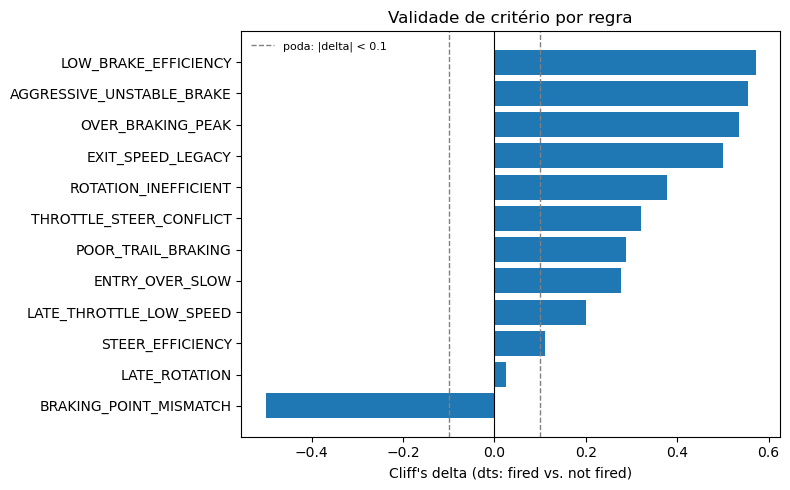

Saved -> fig_criterion_per_rule.png


In [5]:
plot_df = df_criterion.dropna(subset=["cliffs_delta"]).sort_values("cliffs_delta")
fig, ax = plt.subplots(figsize=(8, 5))
if plot_df.empty:
    ax.text(0.5, 0.5, "No criterion data in current scope\n(build the full cache first)",
            ha="center", va="center", transform=ax.transAxes)
else:
    ax.barh(plot_df["Rule_ID"], plot_df["cliffs_delta"], color="tab:blue")
    ax.axvline(0, color="k", lw=0.8)
    ax.axvline(0.1, color="grey", ls="--", lw=1, label="poda: |delta| < 0.1")
    ax.axvline(-0.1, color="grey", ls="--", lw=1)
    ax.set_xlabel("Cliff's delta (dts: fired vs. not fired)")
    ax.legend(fontsize=8, frameon=False)
ax.set_title("Validade de critério por regra")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_criterion_per_rule.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved -> fig_criterion_per_rule.png")

## 3. Matriz de co-ocorrência

`df_sector` (baseline) pivotado: linha = par de setor `(Track, Comparison, Stint,
Sector)`, coluna = `Rule_ID`, valor = `Fired` (0/1). Jaccard e phi entre todas as
regras (12×12).

In [6]:
wide = (df_sector.pivot_table(index=["Track", "Comparison", "Stint", "Sector"],
                              columns="Rule_ID", values="Fired", fill_value=0)
        .reindex(columns=RULE_IDS, fill_value=0))

n = len(RULE_IDS)
jaccard = pd.DataFrame(np.eye(n), index=RULE_IDS, columns=RULE_IDS)
phi     = pd.DataFrame(np.eye(n), index=RULE_IDS, columns=RULE_IDS)

for i, r1 in enumerate(RULE_IDS):
    a = wide[r1].to_numpy().astype(bool)
    for j, r2 in enumerate(RULE_IDS):
        if j <= i:
            continue
        b = wide[r2].to_numpy().astype(bool)
        n11 = int(np.sum(a & b)); n10 = int(np.sum(a & ~b))
        n01 = int(np.sum(~a & b)); n00 = int(np.sum(~a & ~b))
        union = n11 + n10 + n01
        jac = n11 / union if union > 0 else np.nan
        denom = np.sqrt((n11 + n10) * (n01 + n00) * (n11 + n01) * (n10 + n00))
        ph = (n11 * n00 - n10 * n01) / denom if denom > 0 else np.nan
        jaccard.loc[r1, r2] = jaccard.loc[r2, r1] = jac
        phi.loc[r1, r2]     = phi.loc[r2, r1]     = ph

jaccard.to_csv(RESULTS_DIR / "cooccurrence_jaccard.csv")
phi.to_csv(RESULTS_DIR / "cooccurrence_phi.csv")

high_jaccard = []
for i, r1 in enumerate(RULE_IDS):
    for j, r2 in enumerate(RULE_IDS):
        if j <= i:
            continue
        v = jaccard.loc[r1, r2]
        if pd.notna(v) and v > 0.8:
            high_jaccard.append((r1, r2, round(float(v), 3)))

print(f"{len(high_jaccard)} rule pairs with Jaccard > 0.8:")
for r1, r2, v in high_jaccard:
    print(f"  {r1:28s} <-> {r2:28s} : {v}")
print(f"\nSaved -> cooccurrence_jaccard.csv, cooccurrence_phi.csv")

0 rule pairs with Jaccard > 0.8:

Saved -> cooccurrence_jaccard.csv, cooccurrence_phi.csv


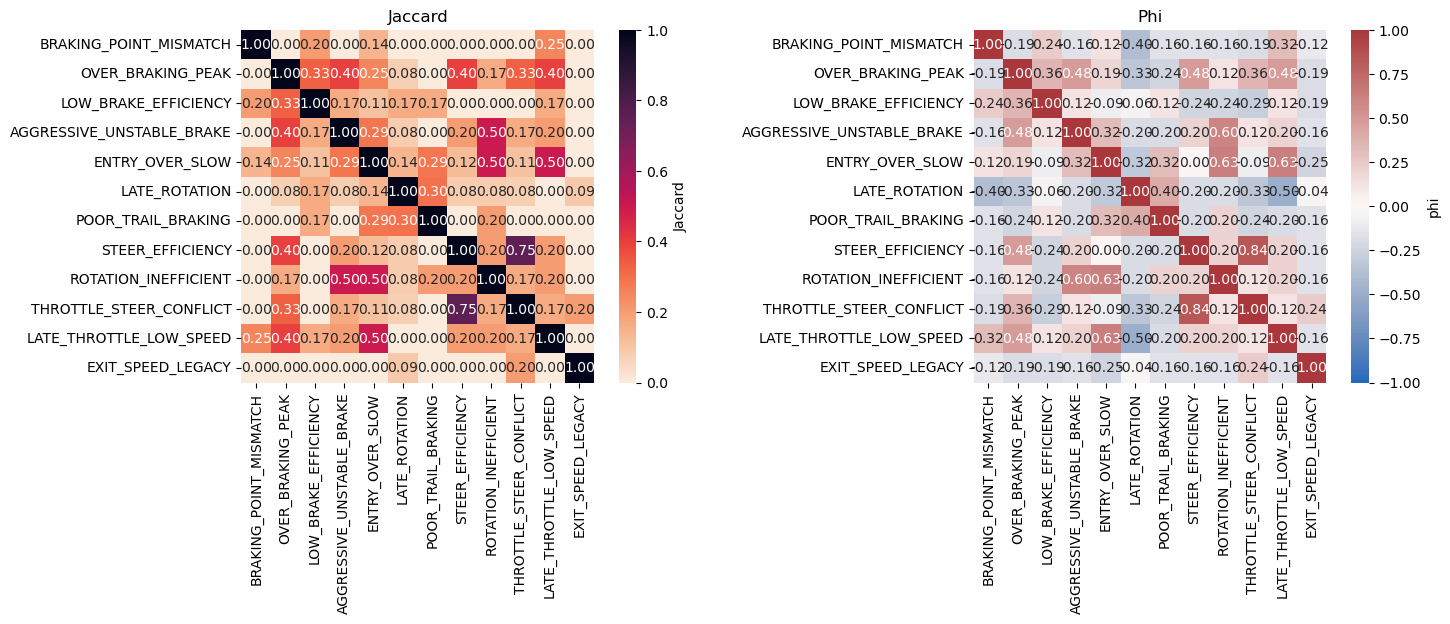

Saved -> fig_cooccurrence_heatmaps.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(jaccard.astype(float), annot=True, fmt=".2f", cmap="rocket_r",
            vmin=0, vmax=1, ax=axes[0], square=True, cbar_kws={"label": "Jaccard"})
axes[0].set_title("Jaccard")
sns.heatmap(phi.astype(float), annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, ax=axes[1], square=True, cbar_kws={"label": "phi"})
axes[1].set_title("Phi")
for ax in axes:
    ax.tick_params(axis="x", rotation=90)
    ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_cooccurrence_heatmaps.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved -> fig_cooccurrence_heatmaps.png")

## 4. Decisão de poda

Uma regra sai da rotulagem se **(Cliff's delta < 0,1 em módulo OU p > 0,05) E
(Jaccard > 0,8 com outra regra)**. Regras com `behavior = None` em `RULE_BEHAVIOR`
nunca entram na rotulagem, independentemente da poda -- são só validação de critério.

In [8]:
max_jaccard = {}
for rid in RULE_IDS:
    others = jaccard.loc[rid].drop(index=rid)
    max_jaccard[rid] = float(others.max()) if not others.empty else np.nan

crit_lookup = df_criterion.set_index("Rule_ID")

prune_rows = []
for rid in RULE_IDS:
    behavior = RULE_BEHAVIOR[rid]
    if behavior is None:
        prune_rows.append({"Rule_ID": rid, "behavior": None, "in_labeling": False,
                           "reason": "criterion-only (RULE_BEHAVIOR = None)"})
        continue
    delta = crit_lookup.loc[rid, "cliffs_delta"]
    pval  = crit_lookup.loc[rid, "p_value"]
    mjac  = max_jaccard[rid]
    weak_criterion = bool(pd.isna(delta) or abs(delta) < 0.1 or pd.isna(pval) or pval > 0.05)
    redundant      = bool(pd.notna(mjac) and mjac > 0.8)
    prune = weak_criterion and redundant
    if prune:
        reason = f"weak criterion (|delta|={delta:.3f}, p={pval:.3f}) AND redundant (max Jaccard={mjac:.3f})"
    elif weak_criterion:
        reason = f"weak criterion (|delta|={delta if pd.isna(delta) else round(delta,3)}, p={pval}) but not redundant -- kept"
    elif redundant:
        reason = f"redundant (max Jaccard={mjac:.3f}) but criterion holds -- kept"
    else:
        reason = "criterion holds and not redundant"
    prune_rows.append({"Rule_ID": rid, "behavior": behavior, "in_labeling": not prune,
                       "reason": reason})

df_rules_in_poc = pd.DataFrame(prune_rows)
df_rules_in_poc.to_csv(RESULTS_DIR / "rules_in_poc.csv", index=False)

n_in = int(df_rules_in_poc["in_labeling"].sum())
print(f"{n_in}/{len(RULE_IDS)} regras entram na rotulagem cega.")
print(f"Saved -> {RESULTS_DIR / 'rules_in_poc.csv'}")
display(df_rules_in_poc)

10/12 regras entram na rotulagem cega.
Saved -> C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\data\poc_threshold_validation\results\rules_in_poc.csv


,Rule_ID,behavior,in_labeling,reason
0,BRAKING_POINT_MISMATCH,brake_point_differs,True,"weak criterion (|delta|=-0.5, p=0.869281045751..."
1,OVER_BRAKING_PEAK,over_braking,True,"weak criterion (|delta|=0.536, p=0.06339869281..."
2,LOW_BRAKE_EFFICIENCY,None,False,criterion-only (RULE_BEHAVIOR = None)
3,AGGRESSIVE_UNSTABLE_BRAKE,brake_application_abrupt,True,"weak criterion (|delta|=0.556, p=0.08210784313..."
4,ENTRY_OVER_SLOW,entry_too_slow,True,"weak criterion (|delta|=0.278, p=0.19225382460..."
5,LATE_ROTATION,rotation_after_vmin,True,"weak criterion (|delta|=0.025, p=0.48270030622..."
6,POOR_TRAIL_BRAKING,no_trail_braking,True,"weak criterion (|delta|=0.289, p=0.24877450980..."
7,STEER_EFFICIENCY,excess_steering,True,"weak criterion (|delta|=0.111, p=0.41176470588..."
8,ROTATION_INEFFICIENT,None,False,criterion-only (RULE_BEHAVIOR = None)
9,THROTTLE_STEER_CONFLICT,throttle_with_steering,True,"weak criterion (|delta|=0.321, p=0.19084967320..."
